# Lending Club Loan Data Analysis

## Objective: 
Create a model that predicts whether or not a loan will be default using
historical data.
## Problem Statement:
For companies like Lending Club correctly predicting whether or not a loan will be a
default is very important. In this project, using historical data from 2007 to 2015, you
have to build a deep learning model to predict the chance of default for future loans.
As you will see later, this dataset is highly imbalanced and includes a lot of features
that make this problem more challenging.
## Domain: Finance
Analysis to be done: Perform data preprocessing and build a deep learning
prediction model.
## Content:
Dataset columns and definition:
- **credit.policy:** 1 if the customer meets the credit underwriting criteria of
LendingClub.com, and 0 otherwise.
- **purpose:** The purpose of the loan (takes values "credit_card",
"debt_consolidation", "educational", "major_purchase", "small_business",
and "all_other").
- **int.rate:** The interest rate of the loan, as a proportion (a rate of 11%
would be stored as 0.11). Borrowers judged by LendingClub.com to be
more risky are assigned higher interest rates.
- **installment:** The monthly installments owed by the borrower if the loan
is funded.
- **log.annual.inc:** The natural log of the self-reported annual income of the
borrower.
- **dti:** The debt-to-income ratio of the borrower (the amount of debt
divided by annual income).
- **fico:** The FICO credit score of the borrower.
- **days.with.cr.line:** The number of days the borrower has had a credit
line.
- **revol.bal:** The borrower's revolving balance (the amount unpaid at the
end of the credit card billing cycle).
- **revol.util:** The borrower's revolving line utilization rate (the amount of
the credit line used relative to total credit available).
- **inq.last.6mths:** The borrower's number of inquiries by creditors in the
last 6 months.
- **delinq.2yrs:** The number of times the borrower has been 30+ days past
due on a payment in the past 2 years.
- **pub.rec:** The borrower's number of derogatory public records
(bankruptcy filings, tax liens, or judgments).
- **not.fully.paid:** 0 → The loan was fully paid. 1 → The loan was not fully
paid (i.e., defaulted, charged off, or missed payments).

In [3]:
import pandas as pd

In [5]:
df = pd.read_csv("loan_data.csv")
df.head()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0


In [6]:
df.tail()

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1
9577,0,debt_consolidation,0.1392,853.43,11.264464,16.28,732,4740.000000,37879,57.0,6,0,0,1


In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9578 entries, 0 to 9577
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   credit.policy      9578 non-null   int64  
 1   purpose            9578 non-null   str    
 2   int.rate           9578 non-null   float64
 3   installment        9578 non-null   float64
 4   log.annual.inc     9578 non-null   float64
 5   dti                9578 non-null   float64
 6   fico               9578 non-null   int64  
 7   days.with.cr.line  9578 non-null   float64
 8   revol.bal          9578 non-null   int64  
 9   revol.util         9578 non-null   float64
 10  inq.last.6mths     9578 non-null   int64  
 11  delinq.2yrs        9578 non-null   int64  
 12  pub.rec            9578 non-null   int64  
 13  not.fully.paid     9578 non-null   int64  
dtypes: float64(6), int64(7), str(1)
memory usage: 1.2 MB


In [10]:
df.describe()

,credit.policy,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid
count,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000,9.578000e+03,9578.000000,9578.000000,9578.000000,9578.000000,9578.000000
mean,0.804970,0.122640,319.089413,10.932117,12.606679,710.846314,4560.767197,1.691396e+04,46.799236,1.577469,0.163708,0.062122,0.160054
std,0.396245,0.026847,207.071301,0.614813,6.883970,37.970537,2496.930377,3.375619e+04,29.014417,2.200245,0.546215,0.262126,0.366676
min,0.000000,0.060000,15.670000,7.547502,0.000000,612.000000,178.958333,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.103900,163.770000,10.558414,7.212500,682.000000,2820.000000,3.187000e+03,22.600000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.122100,268.950000,10.928884,12.665000,707.000000,4139.958333,8.596000e+03,46.300000,1.000000,0.000000,0.000000,0.000000
75%,1.000000,0.140700,432.762500,11.291293,17.950000,737.000000,5730.000000,1.824950e+04,70.900000,2.000000,0.000000,0.000000,0.000000
max,1.000000,0.216400,940.140000,14.528354,29.960000,827.000000,17639.958330,1.207359e+06,119.000000,33.000000,13.000000,5.000000,1.000000


In [26]:
df.columns

Index(['credit.policy', 'purpose', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid',
       'purpose_encoded'],
      dtype='str')

In [12]:
df["purpose"].value_counts()

purpose
debt_consolidation    3957
all_other             2331
credit_card           1262
home_improvement       629
small_business         619
major_purchase         437
educational            343
Name: count, dtype: int64

In [13]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [14]:
df["purpose_encoded"] = le.fit_transform(df["purpose"])

In [15]:
df

,credit.policy,purpose,int.rate,installment,log.annual.inc,dti,fico,days.with.cr.line,revol.bal,revol.util,inq.last.6mths,delinq.2yrs,pub.rec,not.fully.paid,purpose_encoded
0,1,debt_consolidation,0.1189,829.10,11.350407,19.48,737,5639.958333,28854,52.1,0,0,0,0,2
1,1,credit_card,0.1071,228.22,11.082143,14.29,707,2760.000000,33623,76.7,0,0,0,0,1
2,1,debt_consolidation,0.1357,366.86,10.373491,11.63,682,4710.000000,3511,25.6,1,0,0,0,2
3,1,debt_consolidation,0.1008,162.34,11.350407,8.10,712,2699.958333,33667,73.2,1,0,0,0,2
4,1,credit_card,0.1426,102.92,11.299732,14.97,667,4066.000000,4740,39.5,0,1,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9573,0,all_other,0.1461,344.76,12.180755,10.39,672,10474.000000,215372,82.1,2,0,0,1,0
9574,0,all_other,0.1253,257.70,11.141862,0.21,722,4380.000000,184,1.1,5,0,0,1,0
9575,0,debt_consolidation,0.1071,97.81,10.596635,13.09,687,3450.041667,10036,82.9,8,0,0,1,2
9576,0,home_improvement,0.1600,351.58,10.819778,19.18,692,1800.000000,0,3.2,5,0,0,1,4


In [22]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: >

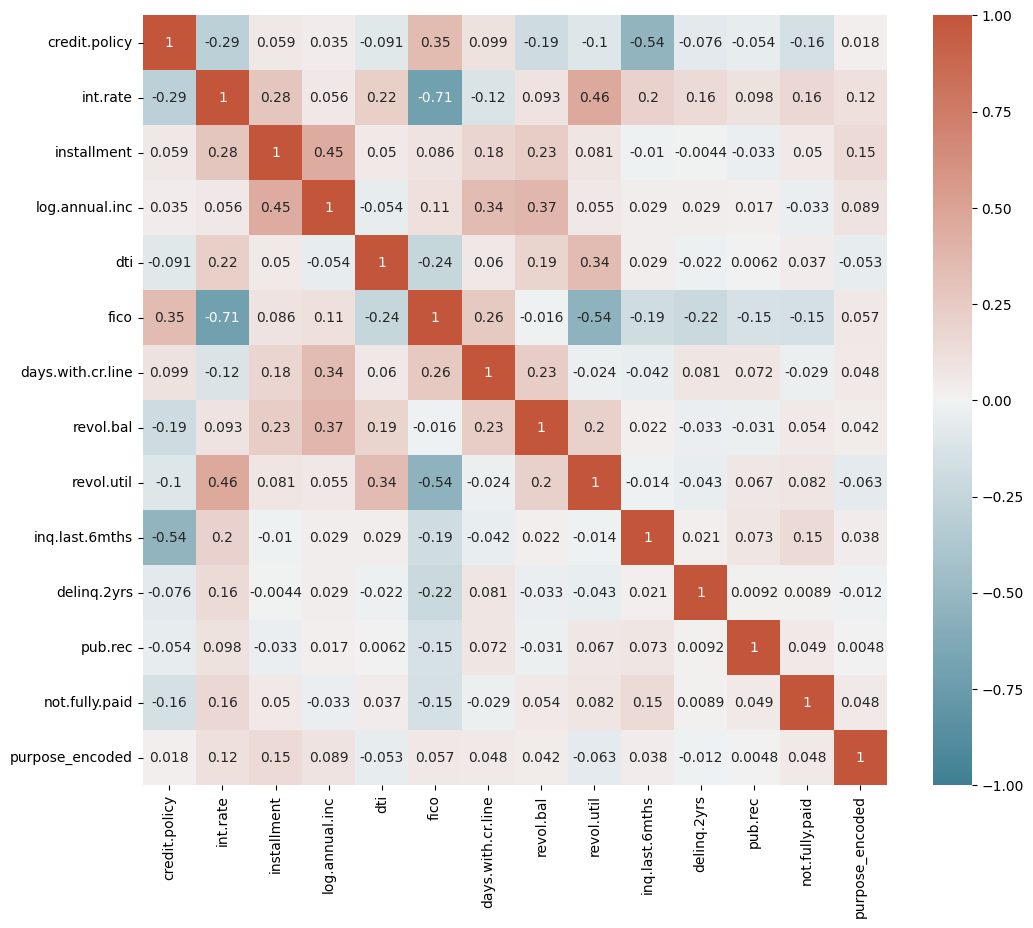

In [25]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(numeric_only=True), annot=True, vmin=-1, vmax=1, cmap=sns.diverging_palette(220, 20, as_cmap=True))

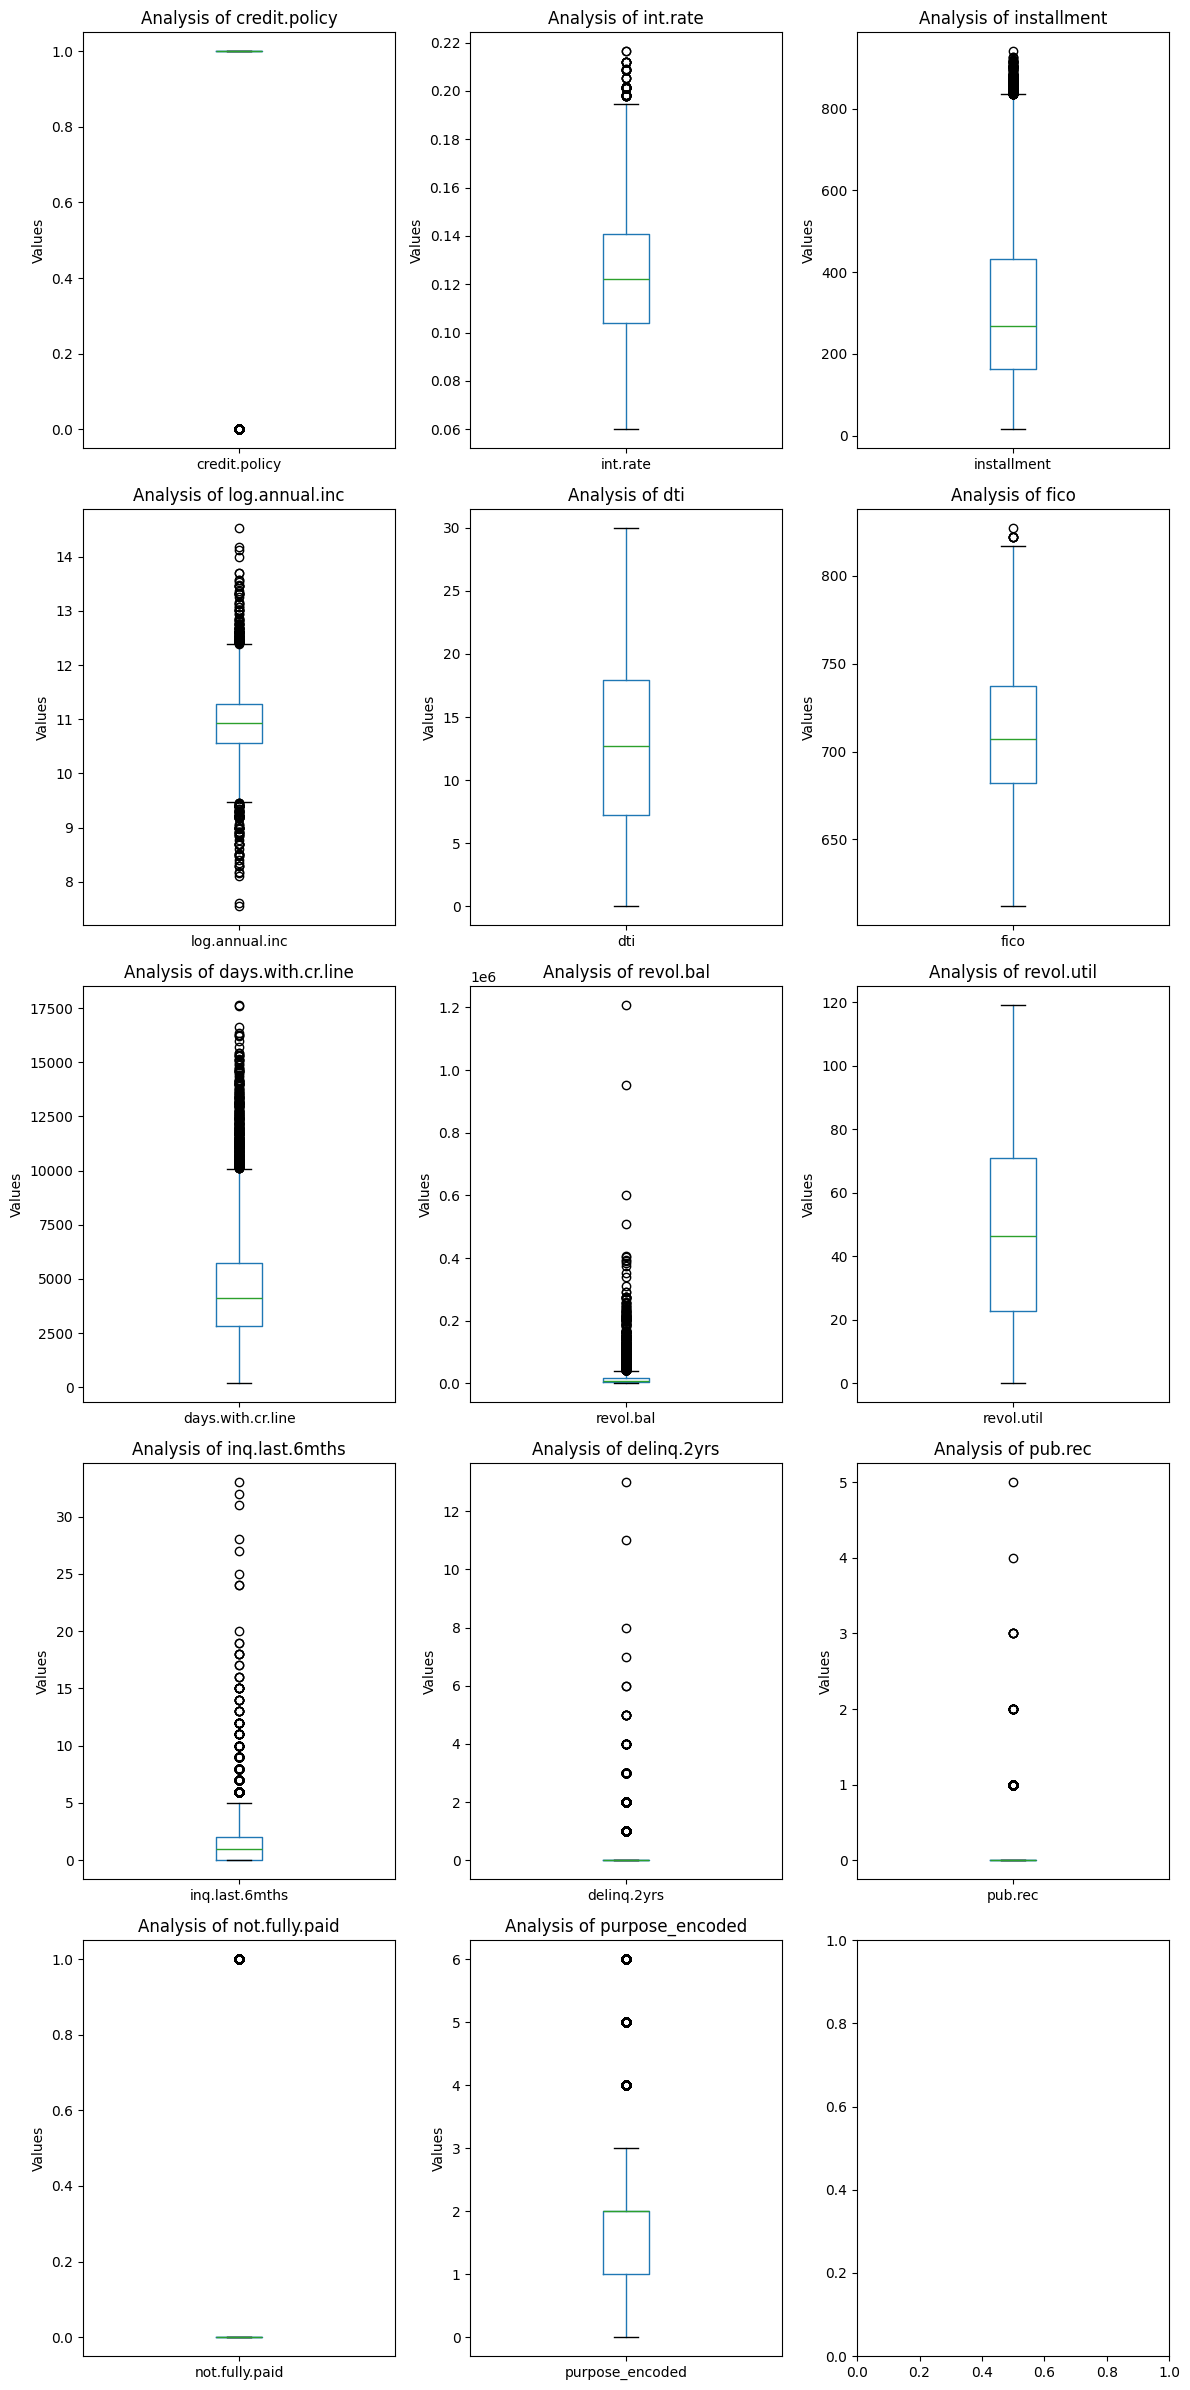

In [28]:
#  create the subplots for each song's properties(numerical only)
numeric_cols = ['credit.policy', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec', 'not.fully.paid',
       'purpose_encoded']
fig, axes = plt.subplots(nrows=5, ncols=3, figsize=(12, 24))

# for more than 1 row - flatten the axes(series type)
axes = axes.flatten()

# plotting a box plot to check the outliers present in each column:
for i, col in enumerate(df[numeric_cols]):
    df.boxplot(column=col, ax=axes[i], grid=False)
    axes[i].set_title(f'Analysis of {col}')
    axes[i].set_ylabel('Values')

plt.tight_layout()
plt.show()

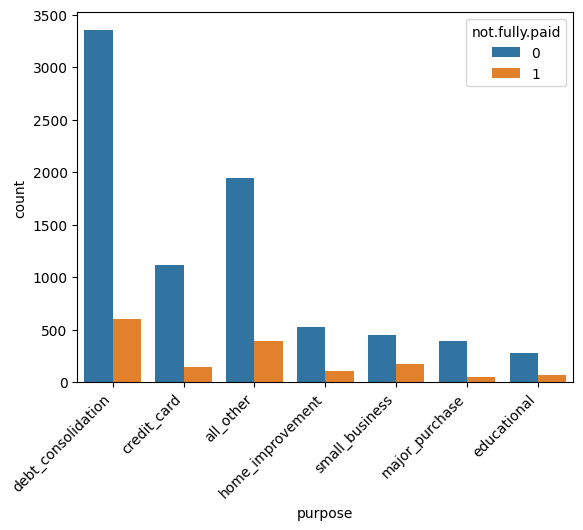

In [58]:
sns.countplot(data=df, x=df["purpose"], hue="not.fully.paid")
plt.xticks(rotation=45, ha='right')
plt.show()

<Axes: xlabel='credit.policy', ylabel='count'>

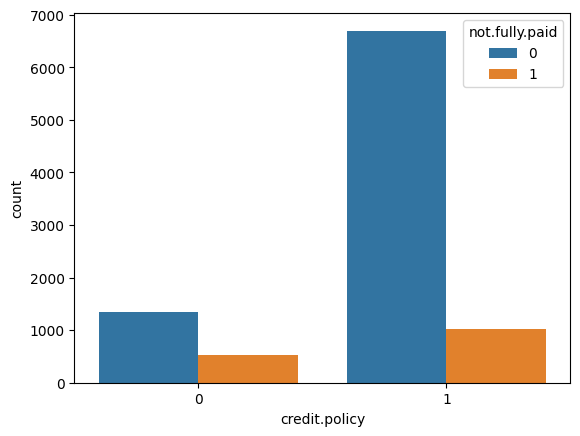

In [57]:
sns.countplot(data=df, x=df["credit.policy"], hue="not.fully.paid")

### SMOTE Technique to fix imbalance data

In [63]:
X = df[['credit.policy', 'int.rate', 'installment', 'log.annual.inc',
       'dti', 'fico', 'days.with.cr.line', 'revol.bal', 'revol.util',
       'inq.last.6mths', 'delinq.2yrs', 'pub.rec',
       'purpose_encoded']]
Y = df['not.fully.paid']

print(Y.count())

9578


In [74]:
from imblearn.over_sampling import SMOTE
os_s = SMOTE()
transformed_X, transformed_Y = os_s.fit_resample(X, Y)
print ("transformed_Y ", transformed_Y.value_counts())

transformed_Y  not.fully.paid
0    8045
1    8045
Name: count, dtype: int64


In [75]:
import tensorflow as tf
from sklearn.model_selection import train_test_split


In [78]:
X_train, X_test, Y_train, Y_test = train_test_split(transformed_X,
                                                    transformed_Y,
                                                    test_size=0.2,
                                                    random_state=27,
                                                    stratify=transformed_Y)
print(f"\nTraining data shape: {X_train.shape}, Testing data shape: {X_test.shape}")


Training data shape: (12872, 13), Testing data shape: (3218, 13)


In [79]:
from tensorflow import keras
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [80]:
model = keras.Sequential([
    # Input layer and first hidden layer
  keras.layers.Dense(X_train.shape[1], activation='relu', input_shape=(X_train.shape[1],)),
    # Second hidden layer
    keras.layers.Dense(50, activation='relu'),
    # Output layer (1 neuron for binary classification, sigmoid activation for probabilities/score)
    keras.layers.Dense(1, activation='sigmoid')
])

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [81]:
model.compile(optimizer='adam',
              loss='binary_crossentropy',
              metrics=['accuracy']) 

In [82]:
print("\nKeras Model Summary:")
model.summary()


Keras Model Summary:


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 13)             │           182 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 50)             │           700 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 933 (3.64 KB)

 Trainable params: 933 (3.64 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train,
                    Y_train,
                    epochs=50,
                    batch_size=32,
                    validation_split=0.1,
                    verbose=0) # verbose=1 shows progress bar

print("Training complete.")

In [ ]:
Y_pb = model.predict(X_test)
# Convert probabilities to binary predictions (0 or 1) using a threshold of 0.5
Y_pred = (y_pb > 0.5).astype(int)

accuracy = accuracy_score(Y_test, y_pred)
print(f"\nModel Accuracy: {accuracy:.4f}")